## Set Up

In [1]:
## Imports

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
## Load Data

df = pd.read_csv("../data/utah_fitness_combined.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

df.head()

,name,zip_code,latitude,longitude,rating,review_count,category,has_online_services,distance,total_pop,median_income,bachelors_degrees,median_age,pct_bachelors
0,The Cliff Spa,84092.0,40.582607,-111.654211,3.6,55,spas,0,119131.962268,28162.0,153333.0,5821.0,42.3,20.669697
1,The Quarry,84604.0,40.264905,-111.669741,4.3,22,rock_climbing,0,118140.506613,43749.0,74522.0,6599.0,23.6,15.083773
2,Tougher Personal Training,84501.0,39.599706,-110.809670,5.0,19,healthtrainers,0,94430.564748,13002.0,53256.0,1069.0,37.1,8.221812
3,Eventful Yoga,84098.0,40.733870,-111.528160,5.0,6,yoga,0,115749.758509,20311.0,171151.0,5789.0,41.9,28.501797
4,3B Yoga,84604.0,40.298546,-111.658005,5.0,13,yoga,0,116876.125055,43749.0,74522.0,6599.0,23.6,15.083773


In [3]:
## Basic Preprocessing
# Remove unrated businesses
df = df[df['rating'] > 0].copy()

# Log transform target
df['log_review_count'] = np.log1p(df['review_count'])

print("Final shape:", df.shape)

Final shape: (868, 15)


In [4]:
## Define Features and Target
target = 'log_review_count'

numeric_features = [
    'rating', 'median_income', 'pct_bachelors',
    'total_pop', 'median_age', 'distance'
]

categorical_features = ['category']

X = df[numeric_features + categorical_features]
y = df[target]

In [5]:
## Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
## Preprocessing Pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## Model 1: Ridge Regression (Baseline)

In [7]:
## Ridge Pipeline

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [8]:
## Hyperparameter Tuning

ridge_params = {
    'model__alpha': [0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Params:", ridge_grid.best_params_)

Best Ridge Params: {'model__alpha': 10.0}


In [9]:
## Evaluate Ridge
ridge_best = ridge_grid.best_estimator_

y_pred_ridge = ridge_best.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", ridge_rmse)
print("Ridge R2:", ridge_r2)

Ridge RMSE: 0.8778344362265019
Ridge R2: 0.046534966664381505


## Model 2: Random Forest

In [10]:
## Random Forest Pipline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [11]:
## Hyperparameter Tuning
rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [12]:
## Evaluate Random Forest
rf_best = rf_grid.best_estimator_

y_pred_rf = rf_best.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 0.7327593816603755
Random Forest R2: 0.33564177138637086


## Cross validation

In [13]:
## Cross Validation Scores
ridge_cv = cross_val_score(
    ridge_best, X_train, y_train,
    cv=5, scoring='neg_root_mean_squared_error'
)

rf_cv = cross_val_score(
    rf_best, X_train, y_train,
    cv=5, scoring='neg_root_mean_squared_error'
)

print("Ridge CV RMSE:", -ridge_cv.mean())
print("RF CV RMSE:", -rf_cv.mean())

Ridge CV RMSE: 1.01138351785819
RF CV RMSE: 0.7971782250857384


In [14]:
## Feature Importance
# Get feature names after preprocessing
feature_names = (
    numeric_features +
    list(rf_best.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_features))
)

importances = rf_best.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
0,rating,0.556043
5,distance,0.106292
2,pct_bachelors,0.080254
1,median_income,0.053800
26,category_gyms,0.045200
3,total_pop,0.039543
4,median_age,0.032562
61,category_yoga,0.012465
28,category_healthtrainers,0.008040
19,category_climbing,0.007534


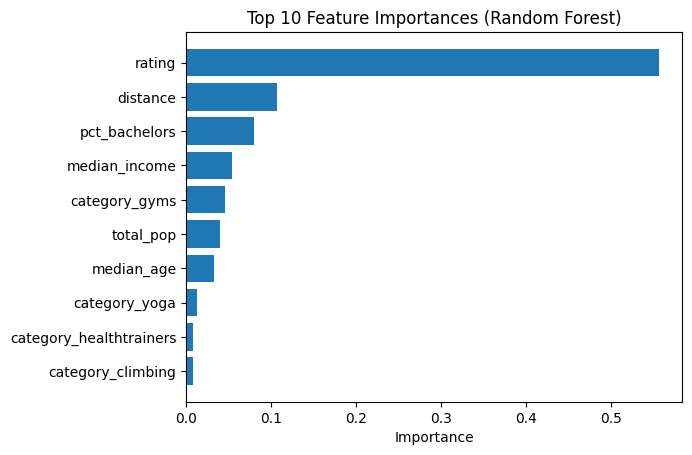

In [15]:
## Plot Feature Importance

top_n = 10
top_features = feature_importance_df.head(top_n)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()